In [1]:
import sys
import pandas as pd
from pathlib import Path

sys.path.append("../modules")

In [2]:
import torch
import pickle
import torch.optim as optim
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.stats import wilcoxon, shapiro
import matplotlib.pyplot as plt
import seaborn as sns

from custom_helpers.config import *

In [3]:
with open("cache/fixed_positions_cache.pkl", "rb") as f:
    fixed_positions_cache = pickle.load(f)

In [4]:
split_type = "easy_split"
data_path_base = Path.cwd().parent / "data"
affinity_df = pd.read_csv(data_path_base / 'processed_data.csv', index_col=0)

train_set_df = affinity_df[affinity_df[split_type] == "train"]
test_set_df = affinity_df[affinity_df[split_type] == "test"]

first_scored_subset = test_set_df.sample(32, random_state=1)
second_scored_subset = test_set_df.sample(32, random_state=2)

scored_subsets = pd.concat(
    [first_scored_subset, second_scored_subset],
    axis=0,
    ignore_index=True
)

In [5]:
results_raml1 = pd.read_csv("final_samples/final_results_raml1.csv")
results_raml2 = pd.read_csv("final_samples/final_results_raml2.csv")
results_raml3 = pd.read_csv("final_samples/final_results_raml3.csv")
results_filtering = pd.read_csv("final_samples/final_results_filtering.csv")
results_proteinmpnn = pd.read_csv("final_samples/final_results_proteinmpnn.csv")

In [6]:
# For each RAML seed, get mean per complex
raml_seed1_means = results_raml1.groupby('complex_id')['dG_pred'].mean()
raml_seed2_means = results_raml2.groupby('complex_id')['dG_pred'].mean()
raml_seed3_means = results_raml3.groupby('complex_id')['dG_pred'].mean()
proteinmpnn_means = results_proteinmpnn.groupby('complex_id')['dG_pred'].mean()
native_scores = results_proteinmpnn.groupby('complex_id')['dG_true'].mean()
filtering_means = results_filtering.groupby('complex_id')['dG_pred'].mean()

raml_seed1_mins = results_raml1.groupby('complex_id')['dG_pred'].min()
raml_seed2_mins = results_raml2.groupby('complex_id')['dG_pred'].min()
raml_seed3_mins = results_raml3.groupby('complex_id')['dG_pred'].min()


# Align by complex_id
common_ids = proteinmpnn_means.index

# Stack the 3 RAML seeds
raml_all_seeds = np.column_stack([
    raml_seed1_means[common_ids],
    raml_seed2_means[common_ids],
    raml_seed3_means[common_ids]
])

raml_all_seeds_min = np.column_stack([
    raml_seed1_mins[common_ids],
    raml_seed2_mins[common_ids],
    raml_seed3_mins[common_ids]
])

# Mean across seeds for each complex
raml_means = raml_all_seeds.mean(axis=1)
raml_mins = raml_all_seeds_min.mean(axis=1)
raml_std = raml_all_seeds.std(axis=1)

# Overall mean ± std
raml_overall_mean = raml_means.mean()
raml_overall_std = raml_means.std()

proteinmpnn_mean = proteinmpnn_means[common_ids].mean()

print(f"ProteinMPNN mean: {proteinmpnn_mean:.3f}")
print(f"Filtering mean: {filtering_means[common_ids].mean():.3f}")
print(f"RAML: {raml_means.mean():.3f}")
print(f"RAML avg min: {raml_mins.mean():.3f}")
print(f"RAML std: {raml_std.mean():.3f}")
print(f"Native scores: {native_scores.mean():.3f}")

ProteinMPNN mean: -9.457
Filtering mean: -9.959
RAML: -9.957
RAML avg min: -10.639
RAML std: 0.141
Native scores: -10.429


In [7]:
import numpy as np

RT = 0.592  # kcal/mol at 298 K

delta_delta_G = proteinmpnn_mean - raml_overall_mean  # or whichever comparison
fold_change = np.exp(delta_delta_G / RT)

print(f"ΔΔG: {delta_delta_G:.3f} kcal/mol")
print(f"Fold difference in affinity: {fold_change:.2f}x")


ΔΔG: 0.500 kcal/mol
Fold difference in affinity: 2.33x


In [8]:
# Test 1: RAML vs ProteinMPNN (using mean across seeds)
stat1, p1 = wilcoxon(raml_means, proteinmpnn_means[common_ids])
print(f"RAML vs ProteinMPNN: p = {p1:.4f}")

# Test 2: Filtering vs ProteinMPNN
stat2, p2 = wilcoxon(filtering_means[common_ids], 
                     proteinmpnn_means[common_ids])
print(f"Filtering vs ProteinMPNN: p = {p2:.4f}")

# Test 3: RAML vs Filtering
stat3, p3 = wilcoxon(raml_means, filtering_means[common_ids])
print(f"RAML vs Filtering: p = {p3:.4f}")

RAML vs ProteinMPNN: p = 0.0000
Filtering vs ProteinMPNN: p = 0.0000
RAML vs Filtering: p = 0.6176


In [9]:
novel_complex_pdbs = scored_subsets['pdb'][~scored_subsets['pdb'].isin((train_set_df['pdb']))]
results_raml2['pdb'] = results_raml2['ID'].str[:4]
results_proteinmpnn['pdb'] = results_proteinmpnn['ID'].str[:4]

novel_complex_results_proteinmpnn = results_proteinmpnn[results_proteinmpnn['pdb'].isin(novel_complex_pdbs)]
novel_complex_results_raml2 = results_raml2[results_raml2['pdb'].isin(novel_complex_pdbs)]

novel_complex_proteinmpnn_means = novel_complex_results_proteinmpnn.groupby('complex_id')['dG_pred'].mean()
novel_complex_seed1_means = novel_complex_results_raml2.groupby('complex_id')['dG_pred'].mean()

print(f"ProteinMPNN mean: {novel_complex_proteinmpnn_means.mean():.3f}")
print(f"RAML: {novel_complex_seed1_means.mean():.3f}")

# Test 1: RAML vs ProteinMPNN (using mean across seeds)
stat1, p1 = wilcoxon(novel_complex_seed1_means, novel_complex_proteinmpnn_means)
print(f"RAML vs ProteinMPNN: p = {p1:.4f}")

ProteinMPNN mean: -9.034
RAML: -9.077
RAML vs ProteinMPNN: p = 0.6406


In [10]:
print(novel_complex_pdbs)

2     3p8m
5     6har
6     5hvf
20    5myk
30    6ous
33    1l0x
34    2ny6
52    3knb
Name: pdb, dtype: object


In [11]:
import pickle

with open("final_samples/all_samples_protein_mpnn.pkl", "rb") as f:
    samples_proteinmpnn = pickle.load(f)

with open("final_samples/all_samples_raml1.pkl", "rb") as f:
    samples_seed1 = pickle.load(f)
    
with open("final_samples/all_samples_raml2.pkl", "rb") as f:
    samples_seed2 = pickle.load(f)
    
with open("final_samples/all_samples_raml3.pkl", "rb") as f:
    samples_seed3 = pickle.load(f)
    
    
all_samples_my_model_pooled = (
    samples_seed1 + 
    samples_seed2 + 
    samples_seed3
)

Interface-Only Sequence Recovery Results:

The Model:
  Mean recovery: 78.8%
  Std: 15.6%
  Range: 33.3% - 100.0%

ProteinMPNN:
  Mean recovery: 55.9%
  Std: 10.2%
  Range: 30.4% - 82.4%

--- Interpretation ---
⚠ Interface recovery is high (>60%)
  Models may be too conservative in redesigning


/tmp/ipykernel_2545472/148391482.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([proteinmpnn_recovery, my_model_recovery],



Plot saved as 'interface_recovery.png'


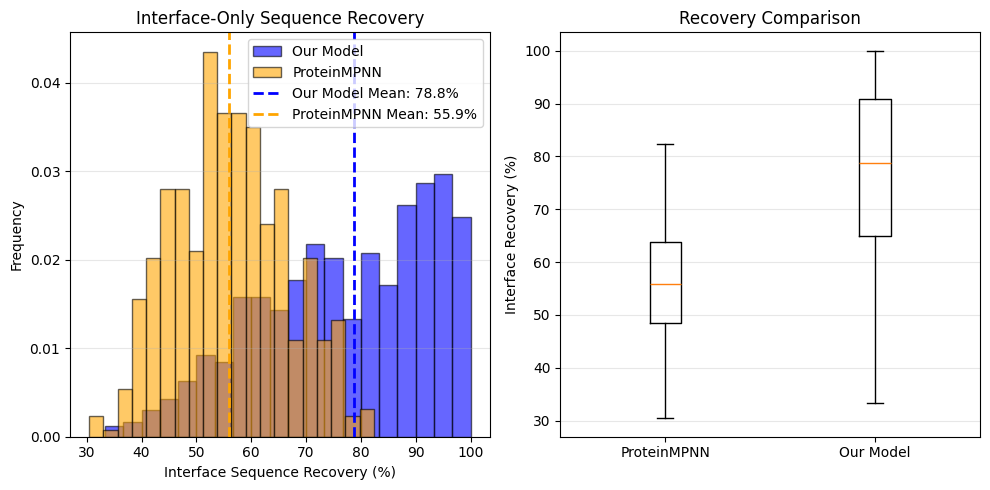

In [30]:
import numpy as np


def calculate_interface_recovery(all_samples, fixed_positions_cache):
    """
    Calculate sequence recovery only at redesigned (non-fixed) positions
    """
    recovery_scores = []
    
    for sample_data in all_samples:
        protein_id = sample_data['protein_id']
        
        # Get sequences
        native_seq = sample_data['native_seq']
        sample_seq = sample_data['sample_seq']
        designed_chains = sample_data['designed_chains']
        
        # Split by chains
        native_chains = native_seq.split('/')
        sample_chains = sample_seq.split('/')
        
        # Get fixed positions for this complex
        fixed_positions = fixed_positions_cache.get(protein_id, {})
        
        # Track matches and total redesigned positions
        total_redesigned = 0
        matches = 0
        
        # Go through each chain
        for chain_idx, chain_name in enumerate(designed_chains):
            if chain_idx >= len(native_chains) or chain_idx >= len(sample_chains):
                continue
                
            native_chain_seq = native_chains[chain_idx]
            sample_chain_seq = sample_chains[chain_idx]
            
            # Get fixed positions for this chain
            chain_fixed = fixed_positions.get(chain_name, [])
            
            # Check each position in the chain
            for pos in range(len(native_chain_seq)):
                # Skip if this position is fixed
                if pos in chain_fixed:
                    continue
                
                # This is a redesigned position
                total_redesigned += 1
                
                # Check if it matches native
                if pos < len(sample_chain_seq) and native_chain_seq[pos] == sample_chain_seq[pos]:
                    matches += 1
        
        # Calculate recovery for this sample
        if total_redesigned > 0:
            recovery = (matches / total_redesigned) * 100
            recovery_scores.append(recovery)
    
    return recovery_scores

# Calculate for both models
my_model_recovery = calculate_interface_recovery(all_samples_my_model_pooled, fixed_positions_cache)
proteinmpnn_recovery = calculate_interface_recovery(samples_proteinmpnn, fixed_positions_cache)

# Print results
print("Interface-Only Sequence Recovery Results:")
print(f"\nThe Model:")
print(f"  Mean recovery: {np.median(my_model_recovery):.1f}%")
print(f"  Std: {np.std(my_model_recovery):.1f}%")
print(f"  Range: {np.min(my_model_recovery):.1f}% - {np.max(my_model_recovery):.1f}%")

print(f"\nProteinMPNN:")
print(f"  Mean recovery: {np.median(proteinmpnn_recovery):.1f}%")
print(f"  Std: {np.std(proteinmpnn_recovery):.1f}%")
print(f"  Range: {np.min(proteinmpnn_recovery):.1f}% - {np.max(proteinmpnn_recovery):.1f}%")

# Interpretation
print("\n--- Interpretation ---")
if 20 <= np.median(my_model_recovery) <= 60:
    print("✓ Interface recovery is in the expected range (20-60%)")
    print("  The model is exploring sequence space appropriately")
else:
    if np.median(my_model_recovery) > 60:
        print("⚠ Interface recovery is high (>60%)")
        print("  Models may be too conservative in redesigning")
    else:
        print("⚠ Interface recovery is low (<20%)")
        print("  Models may be generating very divergent sequences")

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(my_model_recovery, bins=20, alpha=0.6, label='Our Model', edgecolor='black', color='blue', density=True)
plt.hist(proteinmpnn_recovery, bins=20, alpha=0.6, label='ProteinMPNN', edgecolor='black', color='orange', density=True)
plt.axvline(np.median(my_model_recovery), color='blue', linestyle='--', linewidth=2, label=f'Our Model Mean: {np.median(my_model_recovery):.1f}%')
plt.axvline(np.median(proteinmpnn_recovery), color='orange', linestyle='--', linewidth=2, label=f'ProteinMPNN Mean: {np.median(proteinmpnn_recovery):.1f}%')
plt.xlabel('Interface Sequence Recovery (%)')
plt.ylabel('Frequency')
plt.title('Interface-Only Sequence Recovery')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([proteinmpnn_recovery, my_model_recovery], 
            labels=['ProteinMPNN', 'Our Model'])
plt.ylabel('Interface Recovery (%)')
plt.title('Recovery Comparison')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('interface_recovery.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as 'interface_recovery.png'")

# Folds


In [13]:
import pandas as pd

my_df = pd.DataFrame(all_samples_my_model_pooled)
mpnn_df = pd.DataFrame(samples_proteinmpnn)


In [14]:
N = 3

# Use protein_ids that exist in BOTH datasets
common_protein_ids = (
    set(my_df["protein_id"])
    .intersection(set(mpnn_df["protein_id"]))
)

# Convert to sorted list for determinism
common_protein_ids = sorted(common_protein_ids)

# Pick N protein_ids (change to random.sample(...) if you want randomness)
selected_protein_ids = common_protein_ids[:N]

In [15]:
# =========================
# 3. Random 5 per protein (YOUR MODEL)
# =========================
random_my_model = (
    my_df[my_df["protein_id"].isin(selected_protein_ids)]
    .groupby("protein_id", group_keys=False)
    .apply(lambda x: x.sample(n=5, random_state=42))
)

# =========================
# 4. Random 5 per protein (ProteinMPNN)
# =========================
random_mpnn = (
    mpnn_df[mpnn_df["protein_id"].isin(selected_protein_ids)]
    .groupby("protein_id", group_keys=False)
    .apply(lambda x: x.sample(n=5, random_state=42))
)

/tmp/ipykernel_2545472/2283494780.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=5, random_state=42))
/tmp/ipykernel_2545472/2283494780.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=5, random_state=42))


In [16]:
comparison_df = random_my_model.merge(
    random_mpnn,
    on="protein_id",
    suffixes=("_my_model", "_mpnn")
)

comparison_records = comparison_df.to_dict(orient="records")
print(comparison_records)

[{'protein_id': '1AO7:A, B, C, D, E:A_E166A, D_K66A:PMID=23736024', 'sample_n_my_model': 0, 'sample_seq_my_model': 'GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYWDGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDGKDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQRTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGTFQKWAAVVVPSGQEQRYTCHVQHEGLPKPLTLRW', 'native_seq_my_model': 'GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYWDGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDGKDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVAWLRRYLENGKETLQRTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGTFQKWAAVVVPSGQEQRYTCHVQHEGLPKPLTLRW', 'sample_score_my_model': '0.0767', 'designed_chains_my_model': ['A'], 'residue_idx_my_model': {'A': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36, 

In [ ]:
comparison_df = pd.read_csv('folded_sequences/folded_sequences.csv')

sequence_names = {
    "sequence1": '1B2S:A, D:D_A43T:PMID=7739054',
    "sequence2": '1AO7:A, B, C, D, E:A_E166A, D_K66A:PMID=23736024',
    "sequence3": '1B6C:C, D::PMID=10025408'
}

In [28]:
affinity_df

,source,complex_id,pdb,mutstr,ligand,receptor,KD,resolution,release_date,Subgroup,dG,pdb_path,hard_split,medium_split,easy_split
0,SKEMPI v2.0,"1FC2:C, D:C_K31A:PMID=8588944",1fc2,C_K31A,C,D,2.210000e-07,2.80,1981-10-02,NaN,-9.079388,/home/ghandill/masterthesis_lilit_ghandilyan/d...,test,train,train
1,SKEMPI v2.0,"1FC2:C, D:C_N24A:PMID=8588944",1fc2,C_N24A,C,D,4.670000e-08,2.80,1981-10-02,NaN,-10.000306,/home/ghandill/masterthesis_lilit_ghandilyan/d...,test,train,train
2,SKEMPI v2.0,"1FC2:C, D:C_F26A:PMID=8588944",1fc2,C_F26A,C,D,1.870000e-08,2.80,1981-10-02,NaN,-10.542530,/home/ghandill/masterthesis_lilit_ghandilyan/d...,test,train,train
3,SKEMPI v2.0,"1FC2:C, D:C_I27A:PMID=8588944",1fc2,C_I27A,C,D,1.240000e-04,2.80,1981-10-02,NaN,-5.329241,/home/ghandill/masterthesis_lilit_ghandilyan/d...,test,train,val
4,SKEMPI v2.0,"1FC2:C, D::PMID=7716157",1fc2,NaN,C,D,1.500000e-08,2.80,1981-10-02,NaN,-10.673150,/home/ghandill/masterthesis_lilit_ghandilyan/d...,test,train,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,PDBbind v2020,"6Q0O:A, B, Z::PMID=31843892",6q0o,NaN,"B, Z",A,4.000000e-07,3.00,2019-12-18,NaN,-8.727885,/home/ghandill/masterthesis_lilit_ghandilyan/d...,train,test,train
11247,PDBbind v2020,"6Q18:A, H, L::PMID=31843892",6q18,NaN,"H, L",A,6.000000e-07,2.55,2019-12-18,NaN,-8.487666,/home/ghandill/masterthesis_lilit_ghandilyan/d...,train,test,train
11248,PDBbind v2020,"6RHV:C, G, H::PMID=31852826",6rhv,NaN,C,"G, H",6.300000e-08,2.29,2019-12-18,NaN,-9.822932,/home/ghandill/masterthesis_lilit_ghandilyan/d...,train,test,val
11249,PDBbind v2020,"6JWJ:A, C::PMID=31836717",6jwj,NaN,C,A,8.570000e-08,1.58,2019-12-25,NaN,-9.640623,/home/ghandill/masterthesis_lilit_ghandilyan/d...,train,test,train


In [26]:
import os
import json
import numpy as np
import pandas as pd

# Base directory
base_dir = "../folds_metrics"

# Initialize storage
data = {
    'sequence1': {'proteinmpnn': [], 'my_model': []},
    'sequence2': {'proteinmpnn': [], 'my_model': []},
    'sequence3': {'proteinmpnn': [], 'my_model': []}
}

# Read all files
for complex_name in ['sequence1', 'sequence2', 'sequence3']:
    complex_dir = os.path.join(base_dir, complex_name)
    
    for model in ['proteinmpnn', 'my_model']:
        model_dir = os.path.join(complex_dir, model)
        
        # Read 5 sequence files
        for i in range(1, 6):
            json_file = os.path.join(model_dir, f'sequence_{i}_metrics.json')
            
            if os.path.exists(json_file):
                with open(json_file, 'r') as f:
                    metrics = json.load(f)
                    plddt_scores = metrics['plddt']  # list of per-residue pLDDT
                    
                    # Store the full pLDDT array
                    data[complex_name][model].append(np.array(plddt_scores))
                    
                    # print(f"✓ Loaded {complex_name}/{model}/sequence_{i}: {len(plddt_scores)} residues")
            else:
                print(f"✗ Missing: {json_file}")

# Verify structure
print("\n=== Data Structure ===")
for complex_name in data:
    print(f"\n{complex_name}:")
    for model in data[complex_name]:
        n_seqs = len(data[complex_name][model])
        if n_seqs > 0:
            lengths = [len(arr) for arr in data[complex_name][model]]
            print(f"  {model}: {n_seqs} sequences, lengths: {lengths}")

# ========================================
# COMPUTE MEAN pLDDT PER COMPLEX
# ========================================

print("\n=== Mean pLDDT per Complex (all residues) ===")

results_by_complex = []

for complex_name in ['sequence1', 'sequence2', 'sequence3']:
    row = {'complex': complex_name}
    
    for model in ['proteinmpnn', 'my_model']:
        plddt_arrays = data[complex_name][model]
        
        if len(plddt_arrays) > 0:
            # Compute mean pLDDT for each sequence (mean over all positions)
            mean_plddts = [arr.mean() for arr in plddt_arrays]
            
            # Mean and std across 5 sequences
            overall_mean = np.mean(mean_plddts)
            overall_std = np.std(mean_plddts)
            
            row[f'{model}_mean'] = overall_mean
            row[f'{model}_std'] = overall_std
            row[f'{model}_values'] = mean_plddts  # Keep individual values
            
            print(f"{complex_name} - {model}: {overall_mean:.1f} ± {overall_std:.1f}")
            print(f"  Individual: {[f'{x:.1f}' for x in mean_plddts]}")
    
    results_by_complex.append(row)

# Convert to DataFrame
df_results = pd.DataFrame(results_by_complex)
print("\n=== Summary Table ===")
print(df_results[['complex', 'proteinmpnn_mean', 'proteinmpnn_std', 'my_model_mean', 'my_model_std']])

# Overall statistics
print("\n=== Overall Statistics ===")
all_proteinmpnn = []
all_my_model = []

for row in results_by_complex:
    all_proteinmpnn.extend(row['proteinmpnn_values'])
    all_my_model.extend(row['my_model_values'])

print(f"ProteinMPNN overall: {np.mean(all_proteinmpnn):.1f} ± {np.std(all_proteinmpnn):.1f} (n={len(all_proteinmpnn)})")
print(f"My model overall: {np.mean(all_my_model):.1f} ± {np.std(all_my_model):.1f} (n={len(all_my_model)})")

# ========================================
# SAVE DATA FOR LATER USE
# ========================================

# Save organized data
np.savez('plddt_data.npz',
    data=data,  # Full per-residue arrays
    results_by_complex=results_by_complex,  # Summary stats
    all_proteinmpnn=all_proteinmpnn,  # All individual means
    all_my_model=all_my_model
)

print("\n✓ Data saved to plddt_data.npz")

# ========================================
# FOR INTERFACE-SPECIFIC ANALYSIS
# ========================================

print("\n=== Next Step: Interface pLDDT ===")
print("To compute interface-specific pLDDT, you need:")
print("1. Interface residue indices for each complex")
print("2. Then extract: plddt_array[interface_indices].mean()")
print("\nExample code:")
print("""
# Define interface indices for each complex
interface_indices = {
    'sequence1': [10, 11, 12, 25, 26, ...],  # your interface positions
    'sequence2': [5, 6, 20, 21, ...],
    'sequence3': [...]
}

# Compute interface pLDDT
for complex_name in data:
    indices = interface_indices[complex_name]
    for model in data[complex_name]:
        interface_plddts = []
        for plddt_array in data[complex_name][model]:
            interface_plddt = plddt_array[indices].mean()
            interface_plddts.append(interface_plddt)
        print(f"{complex_name} {model}: {np.mean(interface_plddts):.1f}")
""")


=== Data Structure ===

sequence1:
  proteinmpnn: 5 sequences, lengths: [110, 110, 110, 110, 110]
  my_model: 5 sequences, lengths: [110, 110, 110, 110, 110]

sequence2:
  proteinmpnn: 5 sequences, lengths: [274, 274, 274, 274, 274]
  my_model: 5 sequences, lengths: [274, 274, 274, 274, 274]

sequence3:
  proteinmpnn: 5 sequences, lengths: [326, 326, 326, 326, 326]
  my_model: 5 sequences, lengths: [326, 326, 326, 326, 326]

=== Mean pLDDT per Complex (all residues) ===
sequence1 - proteinmpnn: 90.1 ± 1.3
  Individual: ['88.0', '90.6', '91.5', '91.3', '89.3']
sequence1 - my_model: 93.4 ± 1.1
  Individual: ['92.6', '93.5', '94.0', '91.9', '94.9']
sequence2 - proteinmpnn: 88.8 ± 0.5
  Individual: ['88.8', '87.8', '88.8', '89.2', '89.5']
sequence2 - my_model: 89.4 ± 0.2
  Individual: ['89.6', '89.5', '89.5', '89.5', '88.9']
sequence3 - proteinmpnn: 87.8 ± 1.3
  Individual: ['88.2', '86.4', '90.1', '87.4', '87.0']
sequence3 - my_model: 86.8 ± 1.5
  Individual: ['89.6', '85.8', '85.9', '87